# ER 图规模运行时间基准（CD_A / GOLEM / SP / GES）

本 Notebook 对 `d = 5, 10, 15, 20` 的随机 ER 图进行多次 trial，统计四种算法运行时间，并在末尾直接可视化结果。

In [38]:
# 1) 环境与导入
import os
import sys
import time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm

CURRENT_DIR = os.getcwd()
if os.path.exists(os.path.join(CURRENT_DIR, 'synthetic_dataset.py')):
    REPO_ROOT = CURRENT_DIR
elif os.path.basename(CURRENT_DIR) == 'experiments' and os.path.exists(os.path.join(CURRENT_DIR, '..', 'synthetic_dataset.py')):
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
else:
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from MEC import is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_A
from coordinate_descent.coordinate0 import f as cd_A_objective
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega_fit
from coordinate_descent.cd_B_Omega import ell as cd_BOmega_ell

GOLEM_IMPORT_ERROR = None
try:
    golem_src = os.path.join(REPO_ROOT, 'golemMain', 'src')
    if golem_src not in sys.path:
        sys.path.append(golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
except Exception as _e:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = _e

GOLEM_SCORE_IMPORT_ERROR = None
try:
    from models import GolemModel
    from trainers import GolemTrainer
    import tensorflow as tf
    HAS_GOLEM_SCORE_TOOLS = True
except Exception as _e:
    HAS_GOLEM_SCORE_TOOLS = False
    GOLEM_SCORE_IMPORT_ERROR = _e

GES_IMPORT_ERROR = None
try:
    from causallearn.search.ScoreBased.GES import ges as ges_fit
    HAS_GES = True
except Exception as _e:
    HAS_GES = False
    GES_IMPORT_ERROR = _e

print('Repo root             :', REPO_ROOT)
print('HAS_GOLEM             :', HAS_GOLEM)

print('HAS_GOLEM_SCORE_TOOLS :', HAS_GOLEM_SCORE_TOOLS)
print('HAS_GES               :', HAS_GES)

Repo root             : c:\Users\super\DAG
HAS_GOLEM             : True
HAS_GOLEM_SCORE_TOOLS : True
HAS_GES               : True


In [39]:
# 2) 工具函数
@dataclass
class RuntimeRow:
    d: int
    trial_id: int
    seed: int
    algorithm: str
    status: str
    runtime_sec: float
    mec_match: float
    cpdag_shd: float
    score_start: float
    score_end: float
    score_delta: float
    score_rel_change: float
    message: str


def weight_to_binary_adj(W: np.ndarray, threshold: float) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


# 可选：CPDAG-SHD（优先使用 cdt.metrics.SHD_CPDAG，需要 pcalg/R）
try:
    toolbox_path = os.path.join(REPO_ROOT, 'toolbox')
    if toolbox_path not in sys.path:
        sys.path.append(toolbox_path)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray):
    if not HAS_CPDAG_SHD:
        return np.nan
    try:
        return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
    except Exception:
        return np.nan


def ges_graph_to_adj(g: np.ndarray) -> np.ndarray:
    g = np.asarray(g)
    d = g.shape[0]
    A = np.zeros((d, d), dtype=int)

    for i in range(d):
        for j in range(i + 1, d):
            a, b = g[i, j], g[j, i]
            if a == -1 and b == 1:
                A[i, j] = 1
            elif a == 1 and b == -1:
                A[j, i] = 1
            elif a == -1 and b == -1:
                A[i, j] = 1
                A[j, i] = 1
            elif a != 0 or b != 0:
                A[i, j] = int(a != 0)
                A[j, i] = int(b != 0)

    np.fill_diagonal(A, 0)
    return A


def sp_estimate_W(X: np.ndarray) -> np.ndarray:
    from itertools import permutations
    from numpy.linalg import cholesky, inv, LinAlgError

    _, p = X.shape
    if p > 9:
        raise ValueError(f'SP exhaustive search is too expensive for d={p}; please use d<=8.')

    sigma_hat = np.cov(X, rowvar=False)

    def l0_norm(U: np.ndarray, threshold: float = 0.05) -> int:
        return int(np.sum(np.abs(U) > threshold))

    best_score = np.inf
    best_W: Optional[np.ndarray] = None
    best_P: Optional[np.ndarray] = None

    for perm in permutations(range(p)):
        P = np.eye(p)[list(perm)]
        sigma_perm = P @ sigma_hat @ P.T
        try:
            theta = inv(sigma_perm)
            L = cholesky(theta)
            diag_L = np.diag(L)
            sqrt_omega = np.diag(1.0 / diag_L)
            W = np.eye(p) - L @ sqrt_omega
            score = l0_norm(W)
            if score < best_score:
                best_score = score
                best_W = W
                best_P = P
        except LinAlgError:
            continue

    if best_W is None or best_P is None:
        raise RuntimeError('SP failed to find a valid structure.')

    W_est = best_P.T @ best_W @ best_P
    np.fill_diagonal(W_est, 0.0)
    return W_est


def golem_score_from_B(
    X: np.ndarray,
    B: np.ndarray,
    lambda_1: float,
    lambda_2: float,
    equal_variances: bool,
    eps: float = 1e-12,
) -> float:
    Xc = X - X.mean(axis=0, keepdims=True)
    _, d = Xc.shape
    R = Xc - Xc @ B

    if equal_variances:
        sq = float(np.sum(R * R))
        likelihood = 0.5 * d * np.log(max(sq, eps))
    else:
        col_sq = np.sum(R * R, axis=0)
        likelihood = 0.5 * float(np.sum(np.log(np.maximum(col_sq, eps))))

    sign, logdet = np.linalg.slogdet(np.eye(d) - B)
    if sign <= 0 or not np.isfinite(logdet):
        return np.nan

    likelihood = likelihood - float(logdet)
    l1_penalty = float(np.sum(np.abs(B)))
    h_val = float(np.trace(expm(B * B)) - d)
    return likelihood + lambda_1 * l1_penalty + lambda_2 * h_val


def run_golem_with_score_history(
    X: np.ndarray,
    lambda_1: float,
    lambda_2: float,
    equal_variances: bool,
    num_iter: int,
    learning_rate: float,
    seed: int,
    record_every: int = 100,
) -> Tuple[np.ndarray, List[float]]:
    if not HAS_GOLEM_SCORE_TOOLS:
        B_est = golem_fit(
            X,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            equal_variances=equal_variances,
            num_iter=num_iter,
            learning_rate=learning_rate,
            seed=seed,
        )
        B0 = np.zeros_like(B_est)
        s0 = golem_score_from_B(X, B0, lambda_1, lambda_2, equal_variances)
        s1 = golem_score_from_B(X, B_est, lambda_1, lambda_2, equal_variances)
        return np.asarray(B_est), [float(s0), float(s1)]

    Xc = X - X.mean(axis=0, keepdims=True)
    n, d = Xc.shape
    tf.compat.v1.reset_default_graph()
    model = GolemModel(
        n=n,
        d=d,
        lambda_1=lambda_1,
        lambda_2=lambda_2,
        equal_variances=equal_variances,
        seed=seed,
        B_init=None,
    )
    trainer = GolemTrainer(learning_rate=learning_rate)
    model.sess.run(tf.compat.v1.global_variables_initializer())

    score_history: List[float] = []
    B_est = None
    for i in range(0, int(num_iter) + 1):
        if i == 0:
            score, _, _, B_est = trainer.eval_iter(model, Xc)
        else:
            score, _, _, B_est = trainer.train_iter(model, Xc)
        if (i % record_every == 0) or (i == int(num_iter)):
            score_history.append(float(score))

    model.sess.close()
    return np.asarray(B_est), score_history


def run_algorithm(
    algorithm: str,
    X: np.ndarray,
    S: np.ndarray,
    G_true: np.ndarray,
    d: int,
    seed: int,
    cfg: Dict,
) -> Dict[str, object]:
    t0 = time.perf_counter()
    try:
        if algorithm == 'cd_A':
            _, G_est, obj_end = cd_A(
                S=S,
                T=cfg['steps_a'],
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
            )
            score_start = float(cd_A_objective(np.eye(d), S))
            score_end = float(obj_end)

        elif algorithm == 'golem':
            if not HAS_GOLEM:
                return {'status': 'unavailable', 'runtime_sec': np.nan, 'message': str(GOLEM_IMPORT_ERROR)}

            B_est, score_hist = run_golem_with_score_history(
                X=X,
                lambda_1=cfg['golem_lambda1'],
                lambda_2=cfg['golem_lambda2'],
                equal_variances=cfg['golem_equal_variances'],
                num_iter=cfg['golem_num_iter'],
                learning_rate=cfg['golem_learning_rate'],
                seed=seed,
                record_every=cfg['golem_record_every'],
            )
            G_est = weight_to_binary_adj(B_est, threshold=cfg['threshold'])
            if len(score_hist) > 0:
                score_start = float(score_hist[0])
                score_end = float(score_hist[-1])
            else:
                score_start = np.nan
                score_end = np.nan

        elif algorithm == 'sp':
            if d > cfg['sp_max_d']:
                return {'status': 'skipped', 'runtime_sec': np.nan, 'message': f"d={d} > sp_max_d={cfg['sp_max_d']}"}
            B_est = sp_estimate_W(X)
            G_est = weight_to_binary_adj(B_est, threshold=cfg['threshold'])
            score_start = np.nan
            score_end = np.nan

        elif algorithm == 'ges':
            if not HAS_GES:
                return {'status': 'unavailable', 'runtime_sec': np.nan, 'message': str(GES_IMPORT_ERROR)}
            ges_rec = ges_fit(X)
            G_est = ges_graph_to_adj(ges_rec['G'].graph)
            score_start = np.nan
            score_end = np.nan

        elif algorithm == 'cd_BOmega':
            Omega_init = np.eye(d)
            B_est, G_est, _Omega_est, history, _ = cd_BOmega_fit(
                S=S,
                Omega=Omega_init,
                n_epochs=cfg.get('cd_bomega_epochs', 500),
                seed=seed,
                threshold=cfg['threshold'],
                lambda_l0=cfg['lambda_l0'],
                verbose=False,
            )
            score_start = float(cd_BOmega_ell(np.zeros((d, d)), Omega_init, S))
            score_end = float(history[-1]) if history else np.nan

        else:
            return {'status': 'failed', 'runtime_sec': np.nan, 'message': f'Unknown algorithm: {algorithm}'}

        t1 = time.perf_counter()
        score_delta = float(score_end - score_start) if np.isfinite(score_start) and np.isfinite(score_end) else np.nan
        score_rel_change = (
            float((score_end - score_start) / (abs(score_start) + 1e-12))
            if np.isfinite(score_start) and np.isfinite(score_end)
            else np.nan
        )

        return {
            'status': 'ok',
            'runtime_sec': float(t1 - t0),
            'message': '',
            'mec_match': float(int(is_in_markov_equiv_class(G_true, G_est))),
            'cpdag_shd': float(cpdag_shd_score(G_true, G_est)),
            'score_start': float(score_start) if np.isfinite(score_start) else np.nan,
            'score_end': float(score_end) if np.isfinite(score_end) else np.nan,
            'score_delta': score_delta,
            'score_rel_change': score_rel_change,
        }

    except Exception as exc:
        t1 = time.perf_counter()
        return {'status': 'failed', 'runtime_sec': float(t1 - t0), 'message': str(exc)}


def summarize_core(df_trials: pd.DataFrame) -> pd.DataFrame:
    if len(df_trials) == 0:
        return pd.DataFrame(columns=['d', 'algorithm', 'n_total', 'n_ok', 'mec_match_mean', 'cpdag_shd_mean', 'runtime_sec_mean', 'status_counts'])

    grouped = df_trials.groupby(['d', 'algorithm'], as_index=False)
    stat_rows = []
    for _, sub in grouped:
        status_counts = dict(sub['status'].value_counts())
        ok_sub = sub[sub['status'] == 'ok']
        stat_rows.append({
            'd': int(sub['d'].iloc[0]),
            'algorithm': str(sub['algorithm'].iloc[0]),
            'n_total': int(len(sub)),
            'n_ok': int(len(ok_sub)),
            'mec_match_mean': float(ok_sub['mec_match'].mean()) if len(ok_sub) > 0 else np.nan,
            'cpdag_shd_mean': float(ok_sub['cpdag_shd'].mean()) if len(ok_sub) > 0 else np.nan,
            'runtime_sec_mean': float(ok_sub['runtime_sec'].mean()) if len(ok_sub) > 0 else np.nan,
            'status_counts': str(status_counts),
        })

    return pd.DataFrame(stat_rows).sort_values(['d', 'algorithm']).reset_index(drop=True)


def summarize_score(df_trials: pd.DataFrame) -> pd.DataFrame:
    if len(df_trials) == 0:
        return pd.DataFrame(columns=['d', 'algorithm', 'score_start_mean', 'score_end_mean', 'score_delta_mean', 'score_rel_change_mean'])

    score_df = df_trials[df_trials['algorithm'].isin(['cd_A', 'golem', 'cd_BOmega'])].copy()
    score_df = score_df[score_df['status'] == 'ok']
    if len(score_df) == 0:
        return pd.DataFrame(columns=['d', 'algorithm', 'score_start_mean', 'score_end_mean', 'score_delta_mean', 'score_rel_change_mean'])

    out = (
        score_df.groupby(['d', 'algorithm'], as_index=False)
        .agg(
            score_start_mean=('score_start', 'mean'),
            score_end_mean=('score_end', 'mean'),
            score_delta_mean=('score_delta', 'mean'),
            score_rel_change_mean=('score_rel_change', 'mean'),
        )
        .sort_values(['d', 'algorithm'])
        .reset_index(drop=True)
    )
    return out

In [40]:
# 3) 配置
CFG = {
    'trials': 1,
    'seed': 42,
    'n': 3000,
    'd_list': [10, 20, 30],
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 5.0,

    'threshold': 0.05,
    'steps_a': 5000,
    'lambda_l0': 0.0,
    'cd_bomega_epochs': 500,

    'golem_num_iter': 20000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1': 2e-3,
    'golem_lambda2': 5.0,
    'golem_equal_variances': False,
    'golem_record_every': 100,

    'sp_max_d': 8,
}

out_dir = os.path.join(REPO_ROOT, 'experiments', 'results')
os.makedirs(out_dir, exist_ok=True)

# 单算法结果容器（分别运行后再汇总）
trials_by_alg: Dict[str, pd.DataFrame] = {}
summary_core_by_alg: Dict[str, pd.DataFrame] = {}
summary_score_by_alg: Dict[str, pd.DataFrame] = {}

In [41]:
# 4) 单算法运行函数（不混跑）
def run_single_algorithm_benchmark(algorithm_name: str, cfg: Dict):
    rng = np.random.default_rng(cfg['seed'])
    rows: List[RuntimeRow] = []

    for d in cfg['d_list']:
        seeds = rng.integers(0, 10**9, size=cfg['trials'])
        print(f'\n[{algorithm_name}] d={d} start {cfg["trials"]} trial(s)')

        for trial_idx, seed in enumerate(seeds, start=1):
            dataset = SyntheticDataset(
                n=cfg['n'],
                d=d,
                graph_type='ER',
                degree=cfg['degree'],
                noise_type=cfg['noise_type'],
                B_scale=cfg['b_scale'],
                seed=int(seed),
            )

            X = dataset.X
            S = X.T @ X / X.shape[0]
            G_true = weight_to_binary_adj(dataset.B, threshold=0.0)

            res = run_algorithm(algorithm_name, X, S, G_true, d, int(seed), cfg)
            rows.append(RuntimeRow(
                d=d,
                trial_id=trial_idx,
                seed=int(seed),
                algorithm=algorithm_name,
                status=str(res['status']),
                runtime_sec=float(res['runtime_sec']) if ('runtime_sec' in res and pd.notna(res['runtime_sec'])) else np.nan,
                mec_match=float(res['mec_match']) if ('mec_match' in res and pd.notna(res['mec_match'])) else np.nan,
                cpdag_shd=float(res['cpdag_shd']) if ('cpdag_shd' in res and pd.notna(res['cpdag_shd'])) else np.nan,
                score_start=float(res['score_start']) if ('score_start' in res and pd.notna(res['score_start'])) else np.nan,
                score_end=float(res['score_end']) if ('score_end' in res and pd.notna(res['score_end'])) else np.nan,
                score_delta=float(res['score_delta']) if ('score_delta' in res and pd.notna(res['score_delta'])) else np.nan,
                score_rel_change=float(res['score_rel_change']) if ('score_rel_change' in res and pd.notna(res['score_rel_change'])) else np.nan,
                message=str(res.get('message', '')),
            ))

            if res['status'] == 'ok':
                print(f"[{algorithm_name}] d={d} trial {trial_idx:03d}/{cfg['trials']} seed={int(seed)} | t={res['runtime_sec']:.2f}s mec={res['mec_match']:.0f} cpdag={res['cpdag_shd'] if pd.notna(res['cpdag_shd']) else 'NaN'}")
            else:
                print(f"[{algorithm_name}] d={d} trial {trial_idx:03d}/{cfg['trials']} seed={int(seed)} | {res['status']}: {res.get('message', '')}")

    df_trials_alg = pd.DataFrame([r.__dict__ for r in rows])
    df_summary_core_alg = summarize_core(df_trials_alg)
    df_summary_score_alg = summarize_score(df_trials_alg)

    run_tag = f'er_runtime_scaling_notebook_{algorithm_name}'
    trial_csv = os.path.join(out_dir, f'{run_tag}_trials.csv')
    summary_core_csv = os.path.join(out_dir, f'{run_tag}_summary_core.csv')
    summary_score_csv = os.path.join(out_dir, f'{run_tag}_summary_score.csv')

    df_trials_alg.to_csv(trial_csv, index=False)
    df_summary_core_alg.to_csv(summary_core_csv, index=False)
    df_summary_score_alg.to_csv(summary_score_csv, index=False)

    print('\nSaved:', trial_csv)
    print('Saved:', summary_core_csv)
    print('Saved:', summary_score_csv)

    trials_by_alg[algorithm_name] = df_trials_alg
    summary_core_by_alg[algorithm_name] = df_summary_core_alg
    summary_score_by_alg[algorithm_name] = df_summary_score_alg

    display(df_summary_core_alg)
    display(df_summary_score_alg)

    return df_trials_alg, df_summary_core_alg, df_summary_score_alg

In [42]:
# 5) 单独运行 cd_A
df_trials_cd_A, df_summary_core_cd_A, df_summary_score_cd_A = run_single_algorithm_benchmark('cd_A', CFG)


[cd_A] d=10 start 1 trial(s)
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continu

,d,algorithm,n_total,n_ok,mec_match_mean,cpdag_shd_mean,runtime_sec_mean,status_counts
0,10,cd_A,1,1,0.0,15.0,10.576358,{'ok': 1}
1,20,cd_A,1,1,0.0,62.0,29.273472,{'ok': 1}
2,30,cd_A,1,1,0.0,140.0,99.182486,{'ok': 1}


,d,algorithm,score_start_mean,score_end_mean,score_delta_mean,score_rel_change_mean
0,10,cd_A,1.587345e+06,4056.139617,-1.583289e+06,-0.997445
1,20,cd_A,2.033431e+05,269.527174,-2.030735e+05,-0.998675
2,30,cd_A,1.306953e+09,43004.941072,-1.306910e+09,-0.999967


In [43]:
# 6) 单独运行 golem
df_trials_golem, df_summary_core_golem, df_summary_score_golem = run_single_algorithm_benchmark('golem', CFG)


[golem] d=10 start 1 trial(s)
[golem] d=10 trial 001/1 seed=89250953 | t=28.20s mec=0 cpdag=10.0

[golem] d=20 start 1 trial(s)
[golem] d=20 trial 001/1 seed=773956048 | t=34.52s mec=0 cpdag=72.0

[golem] d=30 start 1 trial(s)
[golem] d=30 trial 001/1 seed=654571518 | t=55.69s mec=0 cpdag=158.0

Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_golem_trials.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_golem_summary_core.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_golem_summary_score.csv


,d,algorithm,n_total,n_ok,mec_match_mean,cpdag_shd_mean,runtime_sec_mean,status_counts
0,10,golem,1,1,0.0,10.0,28.198891,{'ok': 1}
1,20,golem,1,1,0.0,72.0,34.524854,{'ok': 1}
2,30,golem,1,1,0.0,158.0,55.693477,{'ok': 1}


,d,algorithm,score_start_mean,score_end_mean,score_delta_mean,score_rel_change_mean
0,10,golem,65.338943,44.215347,-21.123596,-0.323293
1,20,golem,128.291870,87.431267,-40.860603,-0.318497
2,30,golem,205.271774,166.953415,-38.318359,-0.186671


In [44]:
# 7) 单独运行 sp
df_trials_sp, df_summary_core_sp, df_summary_score_sp = run_single_algorithm_benchmark('sp', CFG)


[sp] d=10 start 1 trial(s)
[sp] d=10 trial 001/1 seed=89250953 | skipped: d=10 > sp_max_d=8

[sp] d=20 start 1 trial(s)
[sp] d=20 trial 001/1 seed=773956048 | skipped: d=20 > sp_max_d=8

[sp] d=30 start 1 trial(s)
[sp] d=30 trial 001/1 seed=654571518 | skipped: d=30 > sp_max_d=8

Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_sp_trials.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_sp_summary_core.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_sp_summary_score.csv


,d,algorithm,n_total,n_ok,mec_match_mean,cpdag_shd_mean,runtime_sec_mean,status_counts
0,10,sp,1,0,NaN,NaN,NaN,{'skipped': 1}
1,20,sp,1,0,NaN,NaN,NaN,{'skipped': 1}
2,30,sp,1,0,NaN,NaN,NaN,{'skipped': 1}


,d,algorithm,score_start_mean,score_end_mean,score_delta_mean,score_rel_change_mean


In [45]:
# 8) 单独运行 ges
df_trials_ges, df_summary_core_ges, df_summary_score_ges = run_single_algorithm_benchmark('ges', CFG)


[ges] d=10 start 1 trial(s)
[ges] d=10 trial 001/1 seed=89250953 | t=2.51s mec=0 cpdag=3.0

[ges] d=20 start 1 trial(s)
[ges] d=20 trial 001/1 seed=773956048 | t=27.44s mec=0 cpdag=0.0

[ges] d=30 start 1 trial(s)


invalid value encountered in log


[ges] d=30 trial 001/1 seed=654571518 | t=137.29s mec=0 cpdag=13.0

Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_ges_trials.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_ges_summary_core.csv
Saved: c:\Users\super\DAG\experiments\results\er_runtime_scaling_notebook_ges_summary_score.csv


,d,algorithm,n_total,n_ok,mec_match_mean,cpdag_shd_mean,runtime_sec_mean,status_counts
0,10,ges,1,1,0.0,3.0,2.512183,{'ok': 1}
1,20,ges,1,1,0.0,0.0,27.442998,{'ok': 1}
2,30,ges,1,1,0.0,13.0,137.288180,{'ok': 1}


,d,algorithm,score_start_mean,score_end_mean,score_delta_mean,score_rel_change_mean


In [46]:
# 8.1) 单独运行 cd_BOmega
df_trials_cd_BOmega, df_summary_core_cd_BOmega, df_summary_score_cd_BOmega = run_single_algorithm_benchmark('cd_BOmega', CFG)


[cd_BOmega] d=10 start 1 trial(s)
[cd_BOmega] d=10 trial 001/1 seed=89250953 | t=36.36s mec=0 cpdag=16.0

[cd_BOmega] d=20 start 1 trial(s)
[cd_BOmega] d=20 trial 001/1 seed=773956048 | t=282.91s mec=0 cpdag=74.0

[cd_BOmega] d=30 start 1 trial(s)


overflow encountered in matmul
overflow encountered in reduce


KeyboardInterrupt: 

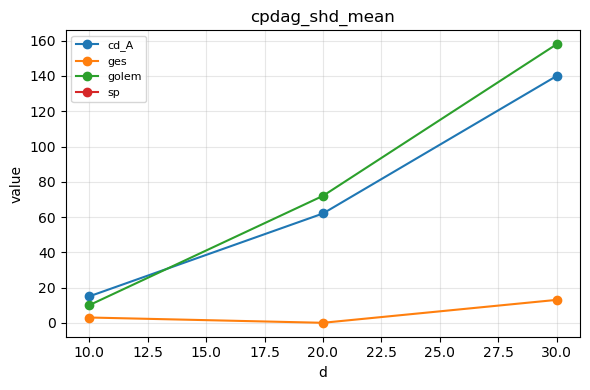

Pivot - cpdag_shd_mean


algorithm,cd_A,ges,golem,sp
d,,,,
10,15.0,3.0,10.0,NaN
20,62.0,0.0,72.0,NaN
30,140.0,13.0,158.0,NaN


In [ ]:
# 9) 可视化核心指标：cpdag_shd_mean（来自单独运行结果）
if len(summary_core_by_alg) == 0:
    print('请先运行第 5~8 个单元中的至少一个算法。')
else:
    df_summary_core = pd.concat([v for v in summary_core_by_alg.values() if len(v) > 0], ignore_index=True)
    if len(df_summary_core) == 0:
        print('没有可视化的核心汇总数据。')
    else:
        metric = 'cpdag_shd_mean'
        piv = df_summary_core.pivot(index='d', columns='algorithm', values=metric).sort_index()

        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        for alg in piv.columns:
            ax.plot(piv.index, piv[alg], marker='o', label=alg)
        ax.set_title(metric)
        ax.set_xlabel('d')
        ax.set_ylabel('value')
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()

        print('Pivot - cpdag_shd_mean')
        display(piv)

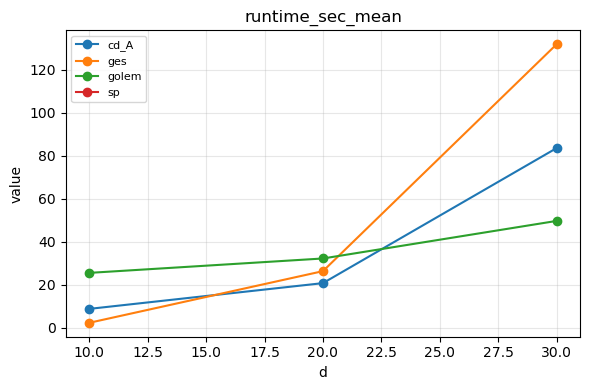

Pivot - runtime_sec_mean


algorithm,cd_A,ges,golem,sp
d,,,,
10,8.861853,2.397989,25.582699,NaN
20,20.823254,26.389725,32.272030,NaN
30,83.543498,131.770995,49.720853,NaN


In [ ]:
# 9.1) 可视化核心指标：runtime_sec_mean（来自单独运行结果）
if len(summary_core_by_alg) == 0:
    print('请先运行第 5~8 个单元中的至少一个算法。')
else:
    df_summary_core = pd.concat([v for v in summary_core_by_alg.values() if len(v) > 0], ignore_index=True)
    if len(df_summary_core) == 0:
        print('没有可视化的核心汇总数据。')
    else:
        metric = 'runtime_sec_mean'
        piv = df_summary_core.pivot(index='d', columns='algorithm', values=metric).sort_index()

        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        for alg in piv.columns:
            ax.plot(piv.index, piv[alg], marker='o', label=alg)
        ax.set_title(metric)
        ax.set_xlabel('d')
        ax.set_ylabel('value')
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
        plt.tight_layout()
        plt.show()

        print('Pivot - runtime_sec_mean')
        display(piv)

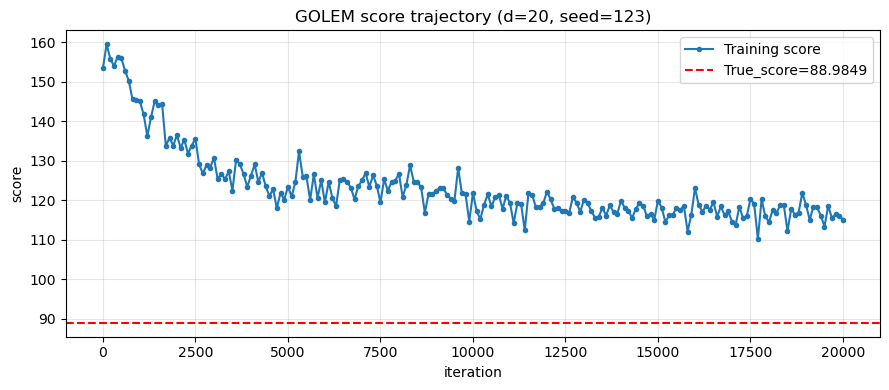

Start score: 153.44070434570312
End score  : 115.0982666015625
True_score : 88.98486898136288


In [ ]:
# 10) 单次训练 score-iter 曲线（固定 d=20）+ True_score 基准线（BOmega公式）
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A_epoch
from coordinate_descent.cd_B_Omega import ell as bo_ell

# -------- 可调参数 --------
ALG_FOR_CURVE = 'golem'   # 'golem' 或 'cd_A'
D_CURVE = 20
SEED_CURVE = 123
EPOCHS_CD_CURVE = 500
GOLEM_NUM_ITER_CURVE = 20000
GOLEM_RECORD_EVERY_CURVE = 100

# 使用当前 CFG 的其它数据生成参数
dataset_curve = SyntheticDataset(
    n=CFG['n'],
    d=D_CURVE,
    graph_type='ER',
    degree=CFG['degree'],
    noise_type=CFG['noise_type'],
    B_scale=CFG['b_scale'],
    seed=SEED_CURVE,
)
X_curve = dataset_curve.X
S_curve = X_curve.T @ X_curve / X_curve.shape[0]
B_true_curve = dataset_curve.B.copy()

# ---- 从数据生成器恢复噪声方差，再构造精度Omega ----
noise_meta = np.asarray(dataset_curve.N)
if noise_meta.ndim == 0:
    var_diag = np.full(D_CURVE, float(noise_meta) ** 2)
elif noise_meta.ndim == 1:
    if noise_meta.size == D_CURVE:
        var_diag = np.square(noise_meta.astype(float))
    else:
        var_diag = np.full(D_CURVE, float(np.mean(noise_meta)) ** 2)
else:
    var_diag = np.var(noise_meta, axis=0, ddof=1)

var_diag = np.maximum(var_diag, 1e-12)
Omega_prec_curve = np.diag(1.0 / var_diag)

if ALG_FOR_CURVE == 'golem':
    if not HAS_GOLEM:
        raise RuntimeError(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')

    B_est_curve, score_hist = run_golem_with_score_history(
        X=X_curve,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=GOLEM_NUM_ITER_CURVE,
        learning_rate=CFG['golem_learning_rate'],
        seed=SEED_CURVE,
        record_every=GOLEM_RECORD_EVERY_CURVE,
)

    # GOLEM分支保持GOLEM自身目标下的true score
    true_score = golem_score_from_B(
        X_curve,
        B_true_curve,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
    )

    iter_axis = np.arange(len(score_hist)) * GOLEM_RECORD_EVERY_CURVE
    if len(iter_axis) > 0:
        iter_axis[-1] = GOLEM_NUM_ITER_CURVE

    plt.figure(figsize=(9, 4))
    plt.plot(iter_axis, score_hist, marker='o', ms=3, label='Training score')
    if np.isfinite(true_score):
        plt.axhline(y=true_score, color='red', linestyle='--', linewidth=1.5, label=f'True_score={true_score:.4f}')
    plt.title(f'GOLEM score trajectory (d={D_CURVE}, seed={SEED_CURVE})')
    plt.xlabel('iteration')
    plt.ylabel('score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Start score:', float(score_hist[0]) if len(score_hist) > 0 else np.nan)
    print('End score  :', float(score_hist[-1]) if len(score_hist) > 0 else np.nan)
    print('True_score :', float(true_score) if np.isfinite(true_score) else np.nan)

elif ALG_FOR_CURVE == 'cd_A':
    # 直接使用 epoch 版本返回的历史score，避免重复实现更新逻辑
    _, _, _, hist_A = cd_A_epoch(
        S=S_curve,
        n_epochs=EPOCHS_CD_CURVE,
        seed=SEED_CURVE,
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        tol=1e-4,
        patience=10,
        min_epochs=50,
        verbose=False,
    )
    score_hist = list(hist_A)

    # True_score 按 BOmega 公式计算（用户要求）
    true_score = float(bo_ell(B_true_curve, Omega_prec_curve, S_curve))

    iter_axis = np.arange(1, len(score_hist) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(iter_axis, score_hist, linewidth=1.2, label='Training score (epoch history)')
    if np.isfinite(true_score):
        plt.axhline(y=true_score, color='red', linestyle='--', linewidth=1.5, label=f'True_score={true_score:.4f}')
    plt.title(f'CD_A epoch score trajectory (d={D_CURVE}, seed={SEED_CURVE})')
    plt.xlabel('epoch')
    plt.ylabel('score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Start score:', float(score_hist[0]) if len(score_hist) > 0 else np.nan)
    print('End score  :', float(score_hist[-1]) if len(score_hist) > 0 else np.nan)
    print('True_score :', float(true_score))

else:
    raise ValueError("ALG_FOR_CURVE must be 'golem' or 'cd_A'")

DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue
DAG/k constraint, continue


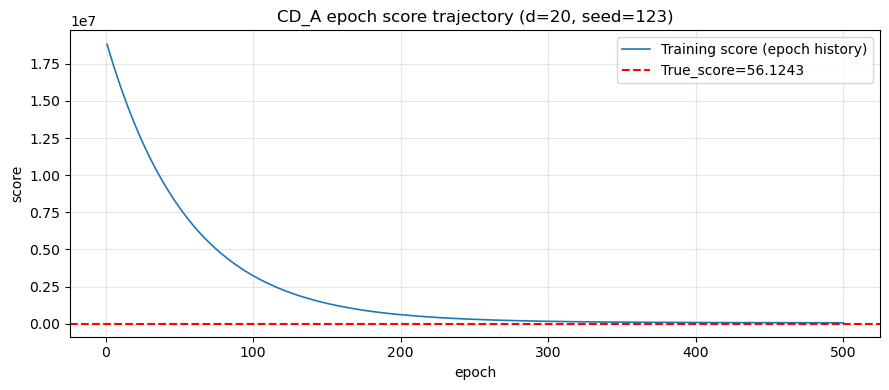

Start score: 18813154.903585326
End score  : 58870.91356768111
True_score : 56.12428176470861


In [ ]:
# 11) 单次训练 score-iter 曲线（固定 d=20）+ True_score 基准线（BOmega公式）
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0_epoch as cd_A_epoch
from coordinate_descent.cd_B_Omega import ell as bo_ell

# -------- 可调参数 --------
ALG_FOR_CURVE = 'cd_A'   # 'golem' 或 'cd_A'
D_CURVE = 20
SEED_CURVE = 123
EPOCHS_CD_CURVE = 500
GOLEM_NUM_ITER_CURVE = 20000
GOLEM_RECORD_EVERY_CURVE = 100

# 使用当前 CFG 的其它数据生成参数
dataset_curve = SyntheticDataset(
    n=CFG['n'],
    d=D_CURVE,
    graph_type='ER',
    degree=CFG['degree'],
    noise_type=CFG['noise_type'],
    B_scale=CFG['b_scale'],
    seed=SEED_CURVE,
)
X_curve = dataset_curve.X
S_curve = X_curve.T @ X_curve / X_curve.shape[0]
B_true_curve = dataset_curve.B.copy()

# ---- 从数据生成器恢复噪声方差，再构造精度Omega ----
noise_meta = np.asarray(dataset_curve.N)
if noise_meta.ndim == 0:
    var_diag = np.full(D_CURVE, float(noise_meta) ** 2)
elif noise_meta.ndim == 1:
    if noise_meta.size == D_CURVE:
        var_diag = np.square(noise_meta.astype(float))
    else:
        var_diag = np.full(D_CURVE, float(np.mean(noise_meta)) ** 2)
else:
    var_diag = np.var(noise_meta, axis=0, ddof=1)

var_diag = np.maximum(var_diag, 1e-12)
Omega_prec_curve = np.diag(1.0 / var_diag)

if ALG_FOR_CURVE == 'golem':
    if not HAS_GOLEM:
        raise RuntimeError(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')

    B_est_curve, score_hist = run_golem_with_score_history(
        X=X_curve,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=GOLEM_NUM_ITER_CURVE,
        learning_rate=CFG['golem_learning_rate'],
        seed=SEED_CURVE,
        record_every=GOLEM_RECORD_EVERY_CURVE,
)

    true_score = golem_score_from_B(
        X_curve,
        B_true_curve,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
    )

    iter_axis = np.arange(len(score_hist)) * GOLEM_RECORD_EVERY_CURVE
    if len(iter_axis) > 0:
        iter_axis[-1] = GOLEM_NUM_ITER_CURVE

    plt.figure(figsize=(9, 4))
    plt.plot(iter_axis, score_hist, marker='o', ms=3, label='Training score')
    if np.isfinite(true_score):
        plt.axhline(y=true_score, color='red', linestyle='--', linewidth=1.5, label=f'True_score={true_score:.4f}')
    plt.title(f'GOLEM score trajectory (d={D_CURVE}, seed={SEED_CURVE})')
    plt.xlabel('iteration')
    plt.ylabel('score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Start score:', float(score_hist[0]) if len(score_hist) > 0 else np.nan)
    print('End score  :', float(score_hist[-1]) if len(score_hist) > 0 else np.nan)
    print('True_score :', float(true_score) if np.isfinite(true_score) else np.nan)

elif ALG_FOR_CURVE == 'cd_A':
    _, _, _, hist_A = cd_A_epoch(
        S=S_curve,
        n_epochs=EPOCHS_CD_CURVE,
        seed=SEED_CURVE,
        threshold=CFG['threshold'],
        lambda_l0=CFG['lambda_l0'],
        tol=1e-4,
        patience=10,
        min_epochs=50,
        verbose=False,
    )
    score_hist = list(hist_A)

    true_score = float(bo_ell(B_true_curve, Omega_prec_curve, S_curve))

    iter_axis = np.arange(1, len(score_hist) + 1)
    plt.figure(figsize=(9, 4))
    plt.plot(iter_axis, score_hist, linewidth=1.2, label='Training score (epoch history)')
    if np.isfinite(true_score):
        plt.axhline(y=true_score, color='red', linestyle='--', linewidth=1.5, label=f'True_score={true_score:.4f}')
    plt.title(f'CD_A epoch score trajectory (d={D_CURVE}, seed={SEED_CURVE})')
    plt.xlabel('epoch')
    plt.ylabel('score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Start score:', float(score_hist[0]) if len(score_hist) > 0 else np.nan)
    print('End score  :', float(score_hist[-1]) if len(score_hist) > 0 else np.nan)
    print('True_score :', float(true_score))

else:
    raise ValueError("ALG_FOR_CURVE must be 'golem' or 'cd_A'")

In [ ]:
# 12) 固定邻接矩阵测试：随机生成 B/N，对比 GES / GOLEM / cd_BOmega 的 runtime 和 cpdag_shd
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as _cd_BOmega
from SCM_data import generate_scm_from_BN


# ---------- 固定邻接矩阵 A ----------
A_fixed = np.array([
  [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],  # 1
  [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0],  # 2
  [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],  # 3
  [0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],  # 4
  [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],  # 5
  [0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],  # 6
  [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],  # 7
  [0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0],  # 8
  [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],  # 9
  [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],  # 10
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],  # 11
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0],  # 12
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],  # 13
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],  # 14
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0],  # 15
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],  # 16
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],  # 17
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],  # 18
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # 19
  [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],  # 20
], dtype=int)

# ---------- 随机生成 B 和 N ----------
_FIXED_SEED = 42
_rng_fixed = np.random.default_rng(_FIXED_SEED)
d_fixed = A_fixed.shape[0]

# 边权重：对每个 A_fixed[i,j]=1 的位置，从 U(0.5,2) 随机采样并随机正负
_magnitudes = _rng_fixed.uniform(1, 10.0, size=(d_fixed, d_fixed))
_signs      = _rng_fixed.choice([-1.0, 1.0], size=(d_fixed, d_fixed))
B_true_fixed = A_fixed * _magnitudes * _signs   # shape (d, d), B[i,j]=weight of i->j

# 噪声方差：每个节点从 U(0.5, 2.0) 采样
var_fixed   = _rng_fixed.uniform(0.5, 0.5, size=d_fixed)
sigma_fixed = np.sqrt(var_fixed)                 # noise std (passed as N to generate_scm_from_BN)
Omega_fixed = np.diag(1.0 / var_fixed)           # precision matrix for cd_BOmega

# ---------- 生成数据 ----------
# generate_scm_from_BN 约定：B[i,j] = X_j 对 X_i 的影响，所以传 B_true_fixed.T
N_FIXED = CFG['n']
X_fixed, _, _, _ = generate_scm_from_BN(
    B_true_fixed.T,
    n_samples=N_FIXED,
    N=var_fixed,       # 方差数组
    seed=_FIXED_SEED,
)
S_fixed  = X_fixed.T @ X_fixed / X_fixed.shape[0]
G_true_fixed = (np.abs(B_true_fixed) > 0).astype(int)

print(f'Graph: d={d_fixed}, edges={int(A_fixed.sum())}')
print(f'Data : n={N_FIXED}, shape={X_fixed.shape}')
print(f'B weights range: [{B_true_fixed[A_fixed==1].min():.3f}, {B_true_fixed[A_fixed==1].max():.3f}]')
print(f'Noise var range : [{var_fixed.min():.3f}, {var_fixed.max():.3f}]')
print()

# ---------- 运行三个算法 ----------
_results_fixed = {}

# --- GES ---
if HAS_GES:
    _t0 = time.perf_counter()
    _ges_rec = ges_fit(X_fixed)
    _t1 = time.perf_counter()
    _G_ges = ges_graph_to_adj(_ges_rec['G'].graph)
    _results_fixed['ges'] = {
        'runtime_sec': _t1 - _t0,
        'cpdag_shd'  : cpdag_shd_score(G_true_fixed, _G_ges),
        'mec_match'  : int(is_in_markov_equiv_class(G_true_fixed, _G_ges)),
    }
    print(f'GES      : runtime={_results_fixed["ges"]["runtime_sec"]:.3f}s  '
          f'cpdag_shd={_results_fixed["ges"]["cpdag_shd"]}  '
          f'mec_match={_results_fixed["ges"]["mec_match"]}')
else:
    print('GES: unavailable')

# --- GOLEM ---
if HAS_GOLEM:
    _t0 = time.perf_counter()
    _B_golem, _ = run_golem_with_score_history(
        X=X_fixed,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=CFG['golem_equal_variances'],
        num_iter=CFG['golem_num_iter'],
        learning_rate=CFG['golem_learning_rate'],
        seed=_FIXED_SEED,
        record_every=CFG['golem_record_every'],
    )
    _t1 = time.perf_counter()
    _G_golem = weight_to_binary_adj(_B_golem, threshold=CFG['threshold'])
    _results_fixed['golem'] = {
        'runtime_sec': _t1 - _t0,
        'cpdag_shd'  : cpdag_shd_score(G_true_fixed, _G_golem),
        'mec_match'  : int(is_in_markov_equiv_class(G_true_fixed, _G_golem)),
    }
    print(f'GOLEM    : runtime={_results_fixed["golem"]["runtime_sec"]:.3f}s  '
          f'cpdag_shd={_results_fixed["golem"]["cpdag_shd"]}  '
          f'mec_match={_results_fixed["golem"]["mec_match"]}')
else:
    print('GOLEM: unavailable')

# --- cd_BOmega ---
_t0 = time.perf_counter()
_, _G_bo, _, _, _ = _cd_BOmega(
    S=S_fixed,
    Omega=Omega_fixed,
    n_epochs=500,
    seed=_FIXED_SEED,
    threshold=CFG['threshold'],
    lambda_l0=CFG['lambda_l0'],
    verbose=False,
)
_t1 = time.perf_counter()
_results_fixed['cd_BOmega'] = {
    'runtime_sec': _t1 - _t0,
    'cpdag_shd'  : cpdag_shd_score(G_true_fixed, _G_bo),
    'mec_match'  : int(is_in_markov_equiv_class(G_true_fixed, _G_bo)),
}
print(f'cd_BOmega: runtime={_results_fixed["cd_BOmega"]["runtime_sec"]:.3f}s  '
      f'cpdag_shd={_results_fixed["cd_BOmega"]["cpdag_shd"]}  '
      f'mec_match={_results_fixed["cd_BOmega"]["mec_match"]}')

# ---------- 汇总表 ----------
print()
_df_fixed = pd.DataFrame(
    [{'algorithm': k, **v} for k, v in _results_fixed.items()]
)[['algorithm', 'runtime_sec', 'cpdag_shd', 'mec_match']]
display(_df_fixed)

Graph: d=20, edges=18
Data : n=3000, shape=(3000, 20)
B weights range: [-9.540, 9.423]
Noise var range : [0.500, 0.500]

GES      : runtime=16.163s  cpdag_shd=7.0  mec_match=0
GOLEM    : runtime=29.865s  cpdag_shd=37.0  mec_match=0
cd_BOmega: runtime=72244.488s  cpdag_shd=44.0  mec_match=0



,algorithm,runtime_sec,cpdag_shd,mec_match
0,ges,16.162781,7.0,0
1,golem,29.865405,37.0,0
2,cd_BOmega,72244.488079,44.0,0
